# 🛠️ Travail réaliser

## Partie 1 — Préparation et exploration des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_excel('../data/data.xlsx',sheet_name="Online Retail")

In [3]:
print("SHape :",data.shape)
print("\nHead :",data.head())

SHape : (541909, 8)

Head :   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [4]:
print("Data types:",data.dtypes)
print("\nDescription :")
print(data.describe(include="all"))

Data types: InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Description :
        InvoiceNo StockCode                         Description  \
count    541909.0    541909                              540455   
unique    25900.0      4070                                4223   
top      573585.0    85123A  WHITE HANGING HEART T-LIGHT HOLDER   
freq       1114.0      2313                                2369   
mean          NaN       NaN                                 NaN   
min           NaN       NaN                                 NaN   
25%           NaN       NaN                                 NaN   
50%           NaN       NaN                                 NaN   
75%           NaN       NaN                                 NaN   
max           NaN       NaN                      

In [5]:
missing=data.isnull().sum()

duplicates=data.duplicated().sum()

print("Missing values:\n",missing)

print("\nNumber of exact duplicates:", duplicates)

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Number of exact duplicates: 5268


In [6]:
cancelled = data["InvoiceNo"].astype(str).str.startswith("C")
print("Cancelled invoices:", cancelled.sum())

Cancelled invoices: 9288


In [7]:
invalid_quantity = data["Quantity"] <= 0

print("Quantity <= 0:", invalid_quantity.sum())

Quantity <= 0: 10624


In [8]:
invalid_price = data["UnitPrice"] <= 0

print("UnitPrice <= 0:", invalid_price.sum())

UnitPrice <= 0: 2517


In [9]:
anomalies=pd.DataFrame({
    "Anomaly":["Cancelled Invoices","Quantity<=0","UnitPrice<=0"],
    "Number of rows":[cancelled.sum(), invalid_quantity.sum(), invalid_price.sum()]
})

print(anomalies)

              Anomaly  Number of rows
0  Cancelled Invoices            9288
1         Quantity<=0           10624
2        UnitPrice<=0            2517


In [10]:
data_clean = data.copy()

#drop rows with missing CustomerID
data_clean = data_clean.dropna(subset=["CustomerID"])

non_product = ["POST", "DOT", "M", "D", "S", "B", "CRUK", "AMAZONFEE","PADS", "C2", "BANK CHARGES"]

data_clean = data_clean[
    (~data_clean["StockCode"].astype(str).str.upper().isin(non_product)) &
    (~data_clean["InvoiceNo"].astype(str).str.startswith("C")) &
    (~data_clean["InvoiceNo"].astype(str).isin(["581483", "541431", "556444"])) &
    (data_clean["Quantity"] > 0) &
    (data_clean["UnitPrice"] > 0)
]

data_clean = data_clean.drop_duplicates()

data_clean["InvoiceDate"] = pd.to_datetime(data_clean["InvoiceDate"])

data_clean["TotalPrice"] = data_clean["Quantity"] * data_clean["UnitPrice"]

print(data_clean.shape)
print(data_clean.head())

(391147, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  


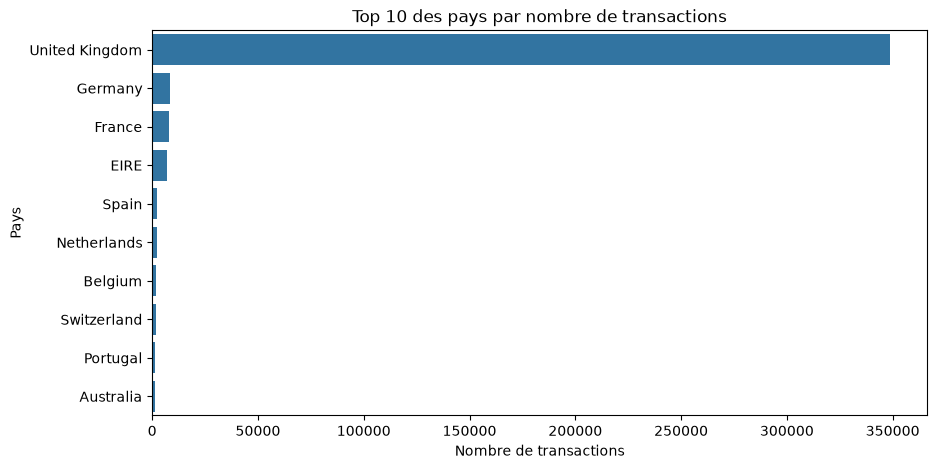

In [11]:
#Transactions by country
country_count=data_clean["Country"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=country_count.values, y=country_count.index)
plt.title("Top 10 des pays par nombre de transactions")
plt.xlabel("Nombre de transactions")
plt.ylabel("Pays")
plt.show()

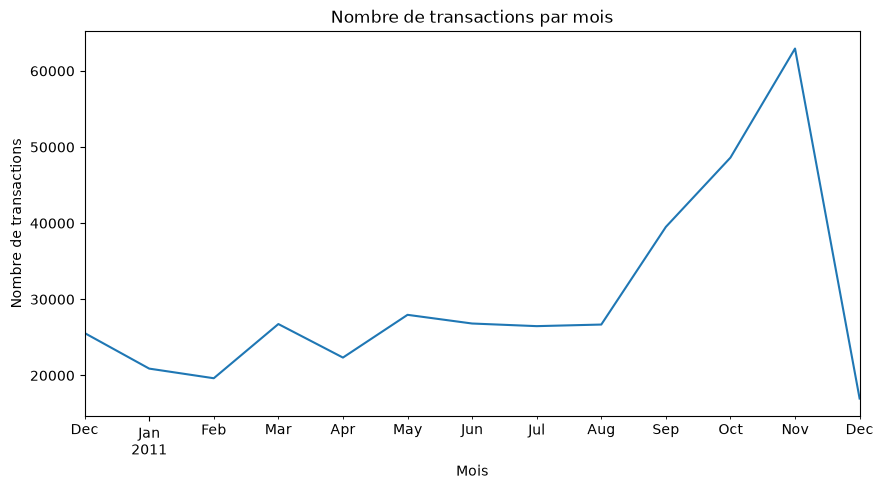

In [12]:
#Transactions by month

monthly=(data_clean.set_index("InvoiceDate").resample("ME").size())
plt.figure(figsize=(10, 5))
monthly.plot()
plt.title("Nombre de transactions par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de transactions")
plt.show()

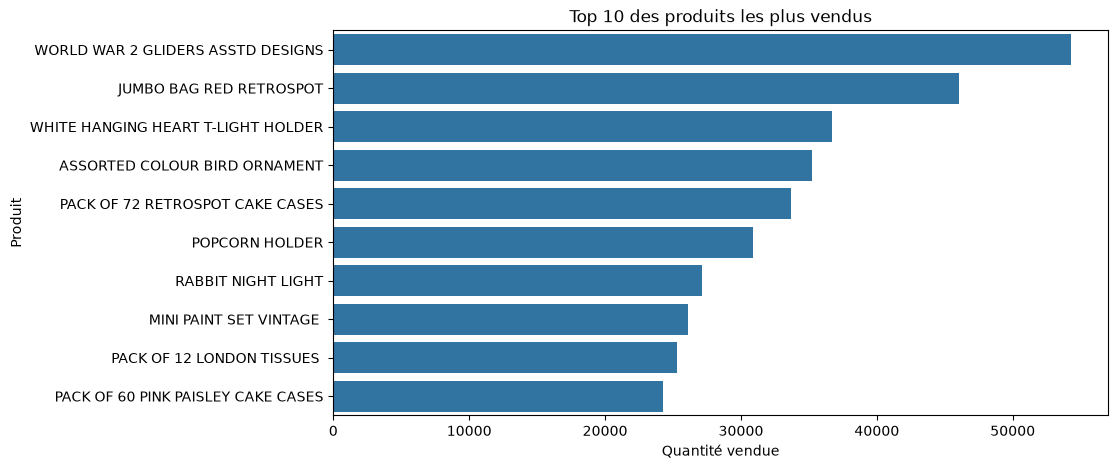

In [13]:
#Top products
top_products=(data_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values,y=top_products.index)
plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Quantité vendue")
plt.ylabel("Produit")
plt.show()

## Partie 2 — Indicateurs RFM

| Indicateur | Définition | Intérêt pour la segmentation |
|---|---|---|
| **Recence** | Nombre de jours entre le dernier achat du client et la date de référence (dernière date du dataset + 1 jour) | Un client récent est plus susceptible de racheter ; une récence élevée signale un risque d'inactivité |
| **Frequence** | Nombre de factures distinctes du client | Mesure la fidélité / régularité d'achat |
| **Montant** | Somme de `Quantity * UnitPrice` du client | Mesure la valeur monétaire du client |

Choix de préparation : lignes sans `CustomerID` supprimées (client non identifiable), doublons exacts supprimés, factures annulées (`C…`), quantités ≤ 0 et prix ≤ 0 exclus (retours/ajustements, non représentatifs du comportement d'achat).

In [14]:
customer_activity = (
    data_clean.groupby("CustomerID")
    .agg(
        Frequency=("InvoiceNo", "nunique"),   # distinct invoices per customer
        Monetary=("TotalPrice", "sum")        # total spend per customer
    )
)

snapshot_date = data_clean["InvoiceDate"].max() + pd.Timedelta(days=1)
customer_recency = (
    snapshot_date - data_clean.groupby("CustomerID")["InvoiceDate"].max()
).dt.days

rfm = customer_activity.copy()
rfm["Recency"] = customer_recency
rfm = rfm[["Recency", "Frequency", "Monetary"]].sort_values("Monetary", ascending=False)

print(rfm.head(10))

            Recency  Frequency   Monetary
CustomerID                               
14646.0           2         72  279138.02
18102.0           1         60  259657.30
17450.0           8         46  194390.79
14911.0           1        198  136161.83
12415.0          24         20  124564.53
14156.0          10         54  116560.08
17511.0           3         31   91062.38
16029.0          39         62   72708.09
16684.0           4         28   66653.56
13694.0           4         50   65039.62


In [15]:
#qcut divides your customers into groups based on their values
#5 divide the customers into 5 groups
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["F_score"] = pd.cut(rfm["Frequency"], [0,1,2,4,9,np.inf], labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5])
print(rfm.head(10))

            Recency  Frequency   Monetary R_score F_score M_score
CustomerID                                                       
14646.0           2         72  279138.02       5       5       5
18102.0           1         60  259657.30       5       5       5
17450.0           8         46  194390.79       5       5       5
14911.0           1        198  136161.83       5       5       5
12415.0          24         20  124564.53       4       5       5
14156.0          10         54  116560.08       5       5       5
17511.0           3         31   91062.38       5       5       5
16029.0          39         62   72708.09       3       5       5
16684.0           4         28   66653.56       5       5       5
13694.0           4         50   65039.62       5       5       5


In [16]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

print(rfm.head(10))

            Recency  Frequency   Monetary R_score F_score M_score RFM_Score
CustomerID                                                                 
14646.0           2         72  279138.02       5       5       5       555
18102.0           1         60  259657.30       5       5       5       555
17450.0           8         46  194390.79       5       5       5       555
14911.0           1        198  136161.83       5       5       5       555
12415.0          24         20  124564.53       4       5       5       455
14156.0          10         54  116560.08       5       5       5       555
17511.0           3         31   91062.38       5       5       5       555
16029.0          39         62   72708.09       3       5       5       355
16684.0           4         28   66653.56       5       5       5       555
13694.0           4         50   65039.62       5       5       5       555


In [17]:
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 4:
        return "Champions"
    
    elif row["R_score"] >= 4 and row["F_score"] >= 3:
        return "Loyal Customers"
    
    elif row["R_score"] >= 4:
        return "Recent Customers"
    
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost Customers"
    
    else:
        return "Potential Customers"


In [18]:
rfm["Segment"]=rfm.apply(segment_customer,axis=1)
print(rfm.head(10))

            Recency  Frequency   Monetary R_score F_score M_score RFM_Score  \
CustomerID                                                                    
14646.0           2         72  279138.02       5       5       5       555   
18102.0           1         60  259657.30       5       5       5       555   
17450.0           8         46  194390.79       5       5       5       555   
14911.0           1        198  136161.83       5       5       5       555   
12415.0          24         20  124564.53       4       5       5       455   
14156.0          10         54  116560.08       5       5       5       555   
17511.0           3         31   91062.38       5       5       5       555   
16029.0          39         62   72708.09       3       5       5       355   
16684.0           4         28   66653.56       5       5       5       555   
13694.0           4         50   65039.62       5       5       5       555   

                        Segment  
CustomerID       

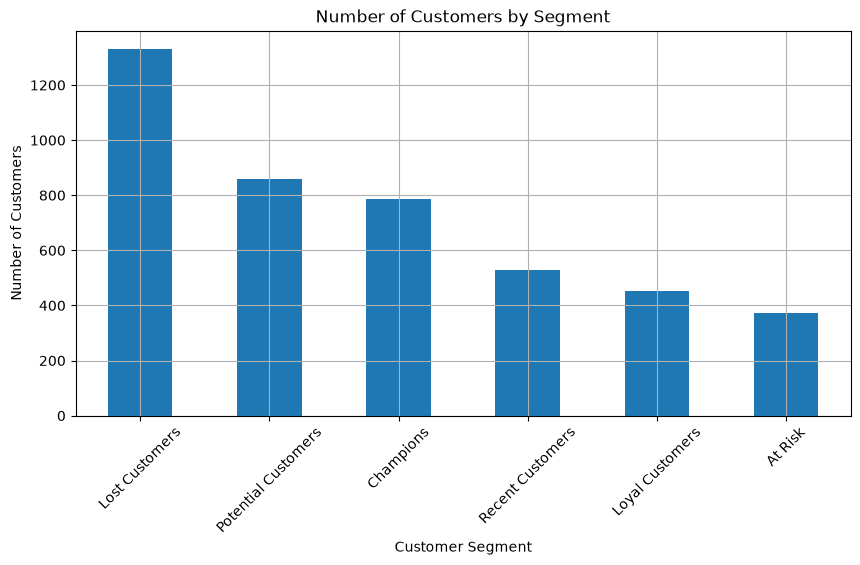

In [19]:
rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
).grid()

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [20]:
segment_analysis = rfm.groupby("Segment").agg(
    Customers=("Monetary", "count"),
    Avg_Monetary=("Monetary", "mean")
)

segment_analysis

,Customers,Avg_Monetary
Segment,,
At Risk,374,1553.503957
Champions,786,6857.543575
Lost Customers,1331,447.990105
Loyal Customers,453,1226.302031
Potential Customers,860,1240.132174
Recent Customers,529,497.658582


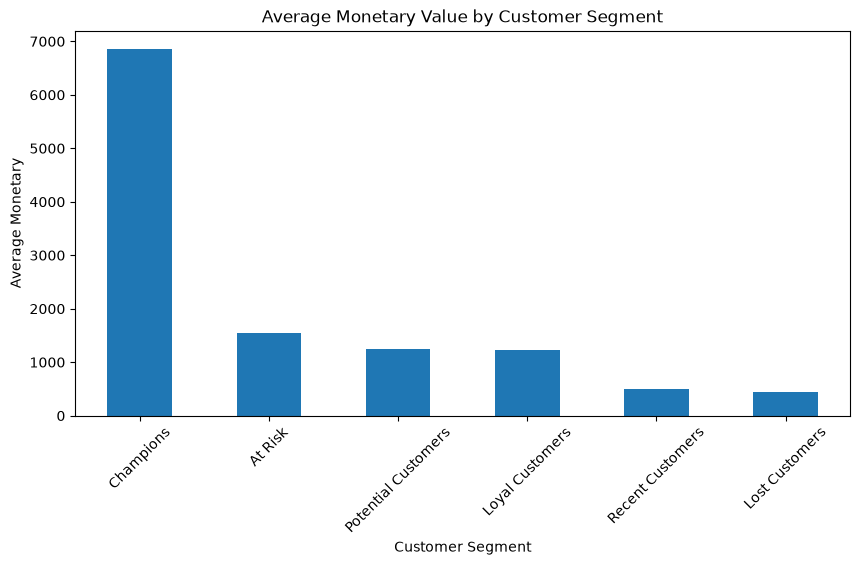

In [21]:
import matplotlib.pyplot as plt

rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary")
plt.xticks(rotation=45)
plt.show()

---
# Partie 3 — Préparation des variables pour le clustering

           Recency    Frequency       Monetary
count  4333.000000  4333.000000    4333.000000
mean     92.696515     4.246250    1950.751082
std     100.130990     7.635847    8441.487099
min       1.000000     1.000000       2.900000
25%      18.000000     1.000000     303.970000
50%      51.000000     2.000000     661.320000
75%     143.000000     5.000000    1625.970000
max     374.000000   206.000000  279138.020000

Skewness :
 Recency       1.242724
Frequency    11.948035
Monetary     21.046863
dtype: float64


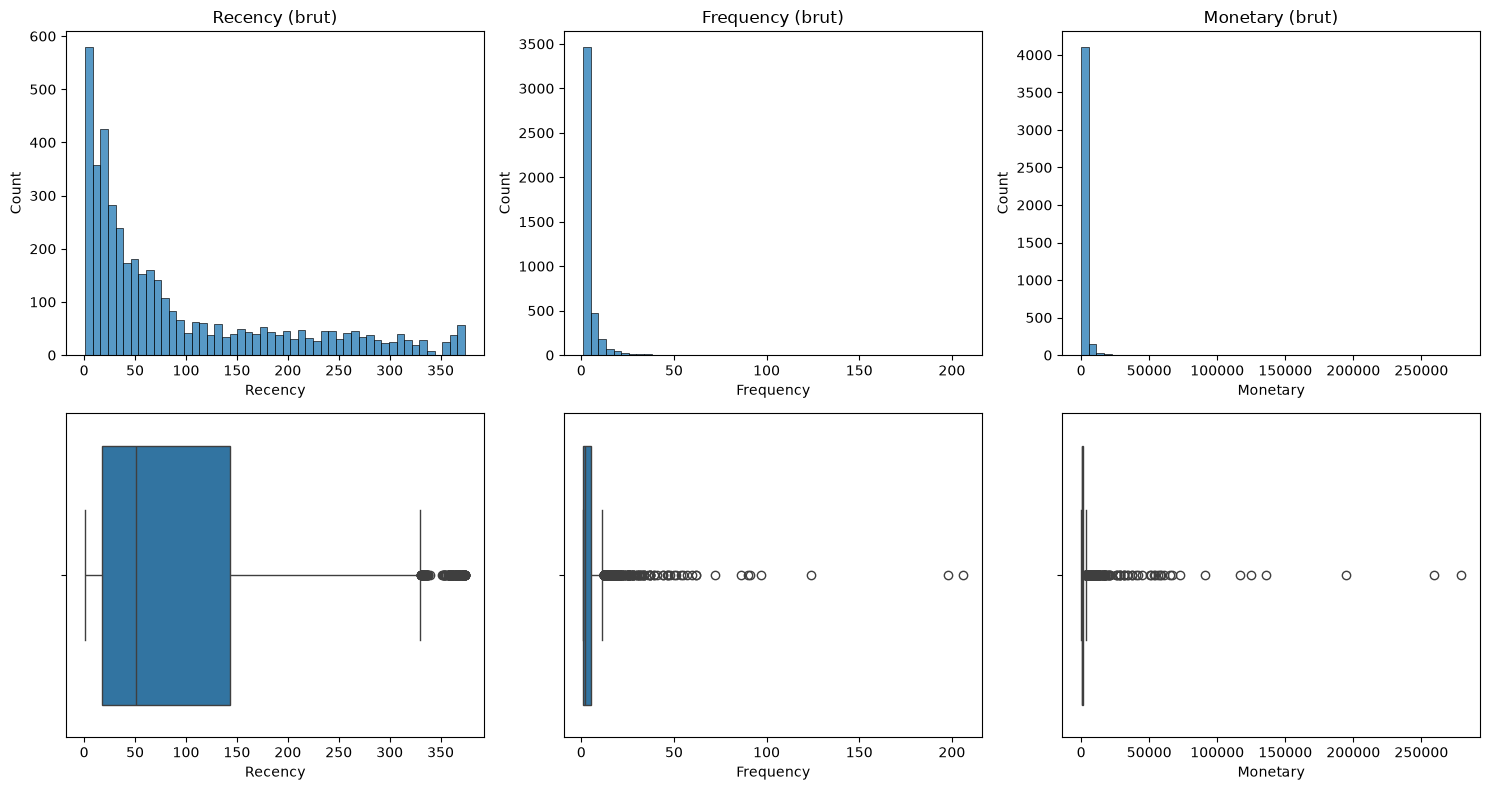

In [22]:
features = ["Recency", "Frequency", "Monetary"]
print(rfm[features].describe())
print("\nSkewness :\n", rfm[features].skew()) #measure of asymmetry

fig,axes=plt.subplots(2,3,figsize=(15,8))
for j,col in enumerate(features):
    sns.histplot(rfm[col],bins=50,ax=axes[0,j])
    axes[0,j].set_title(f"{col} (brut)")
    sns.boxplot(x=rfm[col],ax=axes[1,j])
plt.tight_layout()
plt.show()


Les variables Frequence et Montant sont très asymétriques à droite (quelques clients extrêmes). K-Means, basé sur les distances euclidiennes, serait dominé par ces valeurs extrêmes et par l'échelle de Montant.

Traitement : `log1p` (réduit l'asymétrie, valeurs strictement positives donc sans risque) puis `StandardScaler` (met les trois variables à la même échelle).

Skewness après log1p :
 Recency     -0.378526
Frequency    1.213774
Monetary     0.357319
dtype: float64


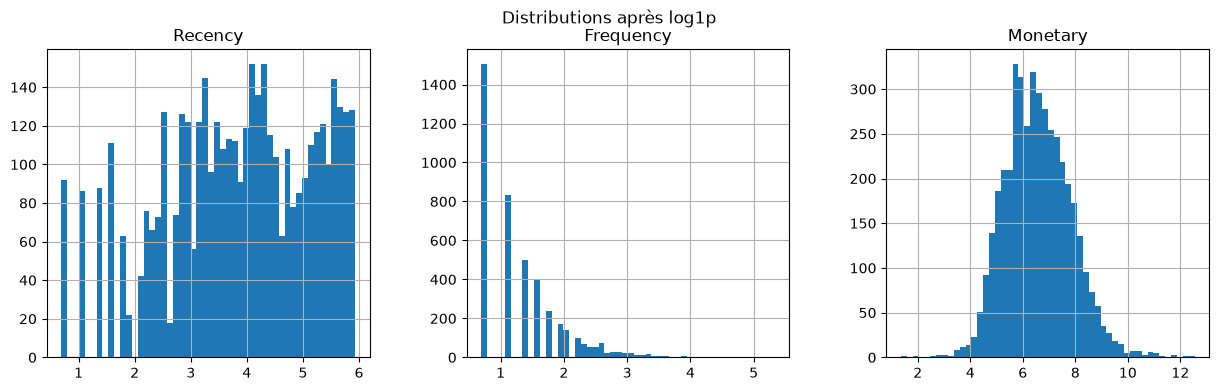

In [23]:
from sklearn.preprocessing import StandardScaler

X_log=np.log1p(rfm[features])
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X_log)

print("Skewness après log1p :\n", X_log.skew())

X_log.hist(bins=50, figsize=(15, 4), layout=(1, 3))
plt.suptitle("Distributions après log1p")
plt.show()

---

# Partie 4 — Segmentation avec K-Means

## 4.1 Recherche d'un nombre de clusters pertinent

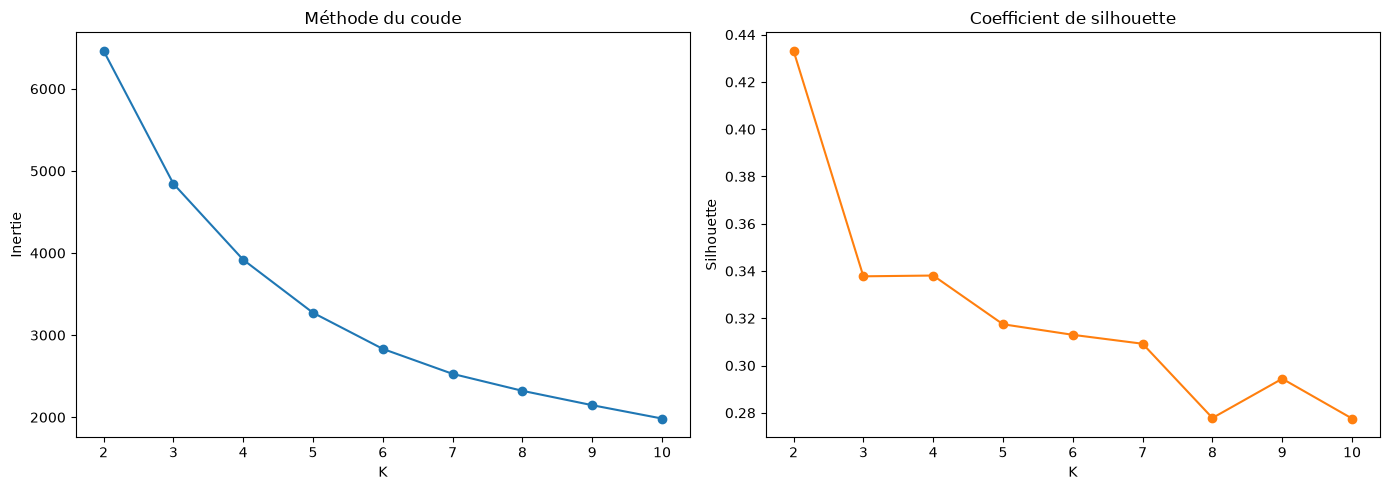

    K    Inertie  Silhouette
0   2  6463.5545      0.4332
1   3  4844.4440      0.3378
2   4  3918.4595      0.3381
3   5  3272.6027      0.3175
4   6  2832.6442      0.3130
5   7  2528.4018      0.3092
6   8  2321.9567      0.2778
7   9  2146.9096      0.2944
8  10  1984.2742      0.2776
K suggéré par la silhouette : 2


In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range=range(2,11)
inertias=[]
silhouettes=[]
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    lab=kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled,lab))

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(list(k_range),inertias,marker="o")
axes[0].set_title("Méthode du coude")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertie")
axes[1].plot(list(k_range), silhouettes, marker="o", color="tab:orange")
axes[1].set_title("Coefficient de silhouette")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

res=pd.DataFrame({"K":list(k_range), "Inertie": inertias, "Silhouette": silhouettes})
print(res.round(4))
print("K suggéré par la silhouette :", res.loc[res["Silhouette"].idxmax(), "K"])

---

## 4.2 Prise en compte de la contrainte métier



## 4.3 Application du K-Means

In [25]:
kmeans=KMeans(n_clusters=3,random_state=42,n_init=10)
rfm["cluster"]=kmeans.fit_predict(X_scaled)
print("Silhouette (k=3) :", round(silhouette_score(X_scaled,rfm["cluster"]),4))
print(rfm["cluster"].value_counts().sort_index())
rfm[features + ["cluster"]].head()


Silhouette (k=3) : 0.3378
cluster
0     760
1    1878
2    1695
Name: count, dtype: int64


,Recency,Frequency,Monetary,cluster
CustomerID,,,,
14646.0,2,72,279138.02,0
18102.0,1,60,259657.30,0
17450.0,8,46,194390.79,0
14911.0,1,198,136161.83,0
12415.0,24,20,124564.53,0


---
# Partie 5 — Profiling et interprétation métier

In [26]:
profil=rfm.groupby("cluster").agg(
    nb_clients=("Monetary","count"),
    recency_moy=("Recency","mean"),
    frequency_moy=("Frequency","mean"),
    monetary_moy=("Monetary","mean"),
    ca_total=("Monetary","sum")
)
profil["part_clients_%"] = profil["nb_clients"] / profil["nb_clients"].sum() * 100
profil["part_CA_%"] = profil["ca_total"] / profil["ca_total"].sum() * 100
profil.round(2)

,nb_clients,recency_moy,frequency_moy,monetary_moy,ca_total,part_clients_%,part_CA_%
cluster,,,,,,,
0,760,16.77,13.35,7571.23,5754135.44,17.54,68.08
1,1878,167.51,1.35,358.46,673185.88,43.34,7.96
2,1695,43.85,3.38,1194.86,2025283.12,39.12,23.96


In [27]:
ordre=profil["monetary_moy"].sort_values(ascending=False).index.tolist()
cluster_names={
    int(ordre[0]):"clients à forte valeur",
    int(ordre[1]):"clients intermédiaires",
    int(ordre[2]):"clients inactifs / occasionnels",
}
rfm["Segment_KMeans"]=rfm["cluster"].map(cluster_names)

profil["Segment"] = profil.index.map(cluster_names)
print(profil.round(2))

         nb_clients  recency_moy  frequency_moy  monetary_moy    ca_total  \
cluster                                                                     
0               760        16.77          13.35       7571.23  5754135.44   
1              1878       167.51           1.35        358.46   673185.88   
2              1695        43.85           3.38       1194.86  2025283.12   

         part_clients_%  part_CA_%                          Segment  
cluster                                                              
0                 17.54      68.08           clients à forte valeur  
1                 43.34       7.96  clients inactifs / occasionnels  
2                 39.12      23.96           clients intermédiaires  


---

# 📈 Partie 6 — Visualisation des segments avec PCA

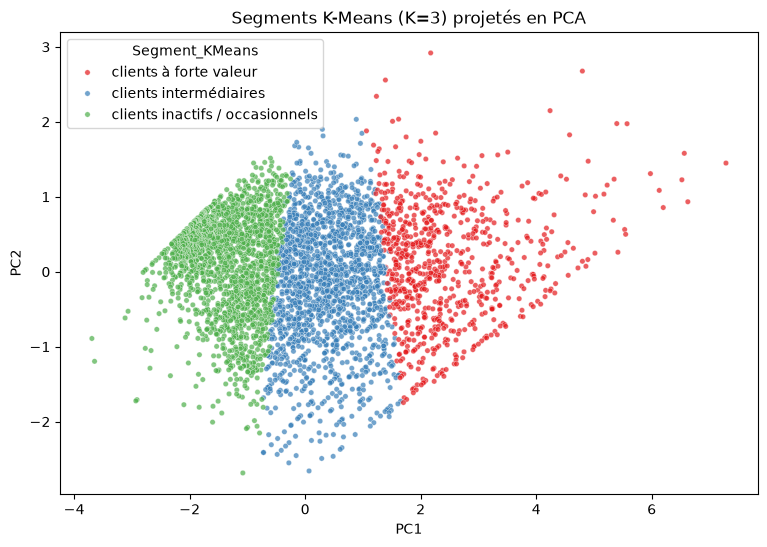

In [28]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_scaled)

plt.figure(figsize=(9,6))
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=rfm["Segment_KMeans"], palette="Set1", s=15, alpha=0.7) #PC1 values (all rows, column 0) PC2 column 1
plt.xlabel("PC1") 
plt.ylabel("PC2")
plt.title("Segments K-Means (K=3) projetés en PCA")
plt.show()

---

# 🌳 Partie 7 — Classification avec Random Forest


In [29]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

x=rfm[features]
y=rfm["cluster"]

x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42,stratify=y
)
print("Train :", x_train.shape, "| Test :", x_test.shape)
print("\nRépartition train :\n", y_train.value_counts(normalize=True).sort_index().round(3))
print("\nRépartition test :\n", y_test.value_counts(normalize=True).sort_index().round(3))

rf=RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)

Train : (3466, 3) | Test : (867, 3)

Répartition train :
 cluster
0    0.175
1    0.433
2    0.391
Name: proportion, dtype: float64

Répartition test :
 cluster
0    0.175
1    0.434
2    0.391
Name: proportion, dtype: float64


---
# Partie 8 — Évaluation

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scores=cross_val_score(rf,x_train,y_train,cv=skf,scoring="f1_macro")

print("F1 scores per fold:", scores)
print("Mean F1:", scores.mean())

rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

a_score=accuracy_score(y_test,y_pred)
p_score=precision_score(y_test,y_pred,average="macro")
r_score=recall_score(y_test,y_pred,average="macro")
f_score=f1_score(y_test,y_pred,average="macro")

print("Accuracy  :",round(a_score,4))
print("Precision :",round(p_score,4))
print("Recall    :",round(r_score,4))
print("F1-score  :",round(f_score,4))

F1 scores per fold: [0.96928883 0.99132468 0.96835553 0.98982906 0.98651852]
Mean F1: 0.9810633241325586
Accuracy  : 0.9792
Precision : 0.979
Recall    : 0.9757
F1-score  : 0.9773


              precision    recall  f1-score   support

           0     0.9799    0.9605    0.9701       152
           1     0.9946    0.9814    0.9880       376
           2     0.9625    0.9853    0.9738       339

    accuracy                         0.9792       867
   macro avg     0.9790    0.9757    0.9773       867
weighted avg     0.9795    0.9792    0.9793       867



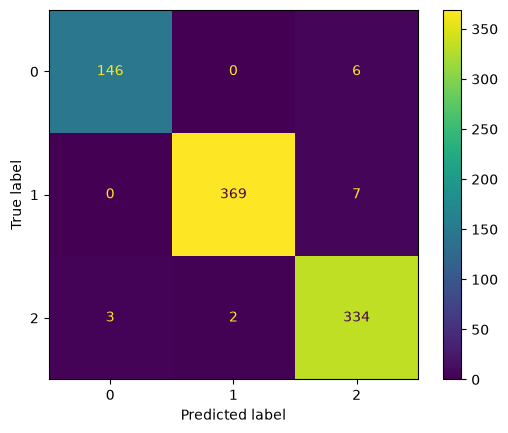

In [31]:
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test,y_pred,digits=4))

confusionMatrix = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
display=ConfusionMatrixDisplay(confusion_matrix=confusionMatrix,display_labels=None)
display.plot()
plt.show()

## Interprétation des résultats

**Stabilité (validation croisée 5 folds sur le train)**
- F1 macro par fold compris entre 0,968 et 0,991, moyenne = 0,981, écart-type ≈ 0,01.
- Les performances varient peu d'un fold à l'autre : le modèle est stable.

**Évaluation finale (jeu de test, 867 clients)**
- Accuracy = 0,979 ; précision macro = 0,979 ; rappel macro = 0,976 ; F1 macro = 0,977.
- Ces valeurs sont très proches de la moyenne obtenue en validation croisée (0,981) : pas de signe de surapprentissage, le modèle généralise.
- F1 par cluster : 0,970 (cluster 0, forte valeur), 0,988 (cluster 1, inactifs/occasionnels), 0,974 (cluster 2, intermédiaires). Aucun cluster n'est mal traité.

**Matrice de confusion**
- 18 erreurs sur 867 clients.
- Les clusters 0 et 1 ne sont jamais confondus entre eux.
- Toutes les erreurs impliquent le cluster 2 (clients intermédiaires) : 6 clients du cluster 0 et 7 du cluster 1 sont prédits comme cluster 2, 3 et 2 clients du cluster 2 sont prédits comme cluster 0 et 1.
- Le cluster 2 a donc la précision la plus faible (0,963), le cluster 0 le rappel le plus faible (0,961).
- Les erreurs concernent des clients proches de la frontière entre deux clusters voisins, ce qui est cohérent avec le profil des clusters (le cluster 2 se situe entre les deux autres en récence, fréquence et montant).

**Limite d'interprétation**
- Les classes proviennent directement du K-Means, calculé sur les mêmes variables R, F, M. Un score élevé signifie que le Random Forest reproduit les règles de segmentation du clustering.
- Cela ne signifie pas qu'il prédit un comportement futur du client.

---

# 🔎 Partie 9 — Importance des variables

Monetary     0.3417
Frequency    0.3413
Recency      0.3171
dtype: float64


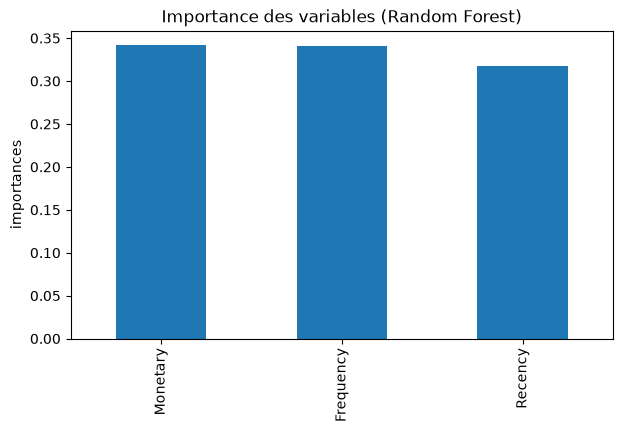

In [32]:
importances=pd.Series(rf.feature_importances_,index=features).sort_values(ascending=False)
print(round(importances,4))

importances.plot(kind="bar",figsize=(7,4),title="Importance des variables (Random Forest)")
plt.ylabel("importances")
plt.show()


---

# 👤 Partie 10 — Prédiction d'un nouveau client

In [33]:
nouveau_client=pd.DataFrame([{"Recency":15,"Frequency":8,"Monetary":3500}])
clus_pred=int(rf.predict(nouveau_client[features])[0])

print("Cluster prédit :", clus_pred)
print("Segment        :", cluster_names[clus_pred])
print("RFM            :", nouveau_client.iloc[0].to_dict())

Cluster prédit : 0
Segment        : clients à forte valeur
RFM            : {'Recency': 15, 'Frequency': 8, 'Monetary': 3500}


---

# 💾 Partie 11 — Sauvegarde du modèle

In [35]:
import joblib, os

os.makedirs("../models",exist_ok=True)
MODEL_PATH = "../models/rf_segmentation.joblib"
joblib.dump({"model":rf,"cluster_names":cluster_names,"features": features}, MODEL_PATH)

bundle=joblib.load(MODEL_PATH)
c=int(bundle["model"].predict(nouveau_client[bundle["features"]])[0])
print("Rechargé -> cluster :", c, "| segment :", bundle["cluster_names"][c])
assert c == clus_pred, "Prédiction incohérente après rechargement"
print("OK : prédiction identique avant/après sauvegarde")

Rechargé -> cluster : 0 | segment : clients à forte valeur
OK : prédiction identique avant/après sauvegarde


Le modèle Random Forest, les noms de segments et la liste des variables sont sauvegardés avec joblib dans `../models/rf_segmentation.joblib`, puis rechargés. La prédiction du modèle rechargé sur le nouveau client est identique à celle du modèle d'origine : le modèle peut être réutilisé sans nouvel entraînement.